In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error as mae
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('C:\\Users\\User\\Desktop\\Deep Learning\\Machine Learning Projects\\Ola Riding Forcasting\\ola.csv')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213


In [24]:
df.shape

(10886, 9)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   temp        10886 non-null  float64
 4   humidity    10886 non-null  float64
 5   windspeed   10886 non-null  float64
 6   casual      10886 non-null  int64  
 7   registered  10886 non-null  int64  
 8   count       10886 non-null  int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 765.6+ KB


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.493937,1.120531,1.0,1.0000,2.00,3.0000,4.00
weather,10886.0,2.491916,1.123139,1.0,1.0000,2.00,4.0000,4.00
temp,10886.0,20.137973,8.696625,5.0,12.6300,20.19,27.7075,35.00
humidity,10886.0,59.946072,22.987200,20.0,40.0400,59.97,79.6200,99.98
windspeed,10886.0,24.960981,14.424684,0.0,12.5225,25.00,37.4275,49.99
casual,10886.0,24.517545,14.390014,0.0,12.0000,25.00,37.0000,49.00
registered,10886.0,99.551442,57.541131,0.0,50.0000,100.00,149.0000,199.00
count,10886.0,124.068988,59.449265,0.0,74.0000,124.00,174.0000,248.00


In [27]:
parts = df['datetime'].str.split(" ", n=2, expand=True)
df['date'] = parts[0]
df['time'] = parts[1].str[:2].astype('int')
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133,2011-01-01,0
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220,2011-01-01,1
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131,2011-01-01,2
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53,2011-01-01,3
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213,2011-01-01,4


In [28]:
from datetime import datetime

df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day

In [29]:
def weekend_or_weekday(year, month, day):
  try:
    d = datetime(year, month, day)
    return 0 if d.weekday() > 4 else 1
  except ValueError:
    return np.nan

In [30]:
df['weekday'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), axis=1)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,year,month,day,weekday
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133,2011-01-01,0,2011,1,1,0
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220,2011-01-01,1,2011,1,1,0
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131,2011-01-01,2,2011,1,1,0
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53,2011-01-01,3,2011,1,1,0
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213,2011-01-01,4,2011,1,1,0


In [31]:
def am_or_pm(x):
  if x > 11:
    return 1
  else:
    return 0

df['am_or_pm'] = df['time'].apply(am_or_pm)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,year,month,day,weekday,am_or_pm
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133,2011-01-01,0,2011,1,1,0,0
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220,2011-01-01,1,2011,1,1,0,0
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131,2011-01-01,2,2011,1,1,0,0
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53,2011-01-01,3,2011,1,1,0,0
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213,2011-01-01,4,2011,1,1,0,0


In [32]:
import holidays

def is_holiday(x):
  ban_holidays = holidays.country_holidays('BD')
  if x in ban_holidays:
    return 1
  else:
    return 0

df['is_holiday'] = df['date'].apply(is_holiday)
df.head()

,datetime,season,weather,temp,humidity,windspeed,casual,registered,count,date,time,year,month,day,weekday,am_or_pm,is_holiday
0,2011-01-01 00:00:00,3,2,6.66,76.62,9.57,5,128,133,2011-01-01,0,2011,1,1,0,0,0
1,2011-01-01 01:00:00,4,3,13.54,55.91,4.01,36,184,220,2011-01-01,1,2011,1,1,0,0,0
2,2011-01-01 02:00:00,1,3,29.58,20.97,33.61,34,97,131,2011-01-01,2,2011,1,1,0,0,0
3,2011-01-01 03:00:00,3,1,7.40,61.64,15.85,6,47,53,2011-01-01,3,2011,1,1,0,0,0
4,2011-01-01 04:00:00,3,4,30.66,98.71,11.47,14,199,213,2011-01-01,4,2011,1,1,0,0,0


In [33]:
df.drop(['datetime', 'date'], axis=1, inplace=True)

In [34]:
df.isnull().sum()

season        0
weather       0
temp          0
humidity      0
windspeed     0
casual        0
registered    0
count         0
time          0
year          0
month         0
day           0
weekday       0
am_or_pm      0
is_holiday    0
dtype: int64

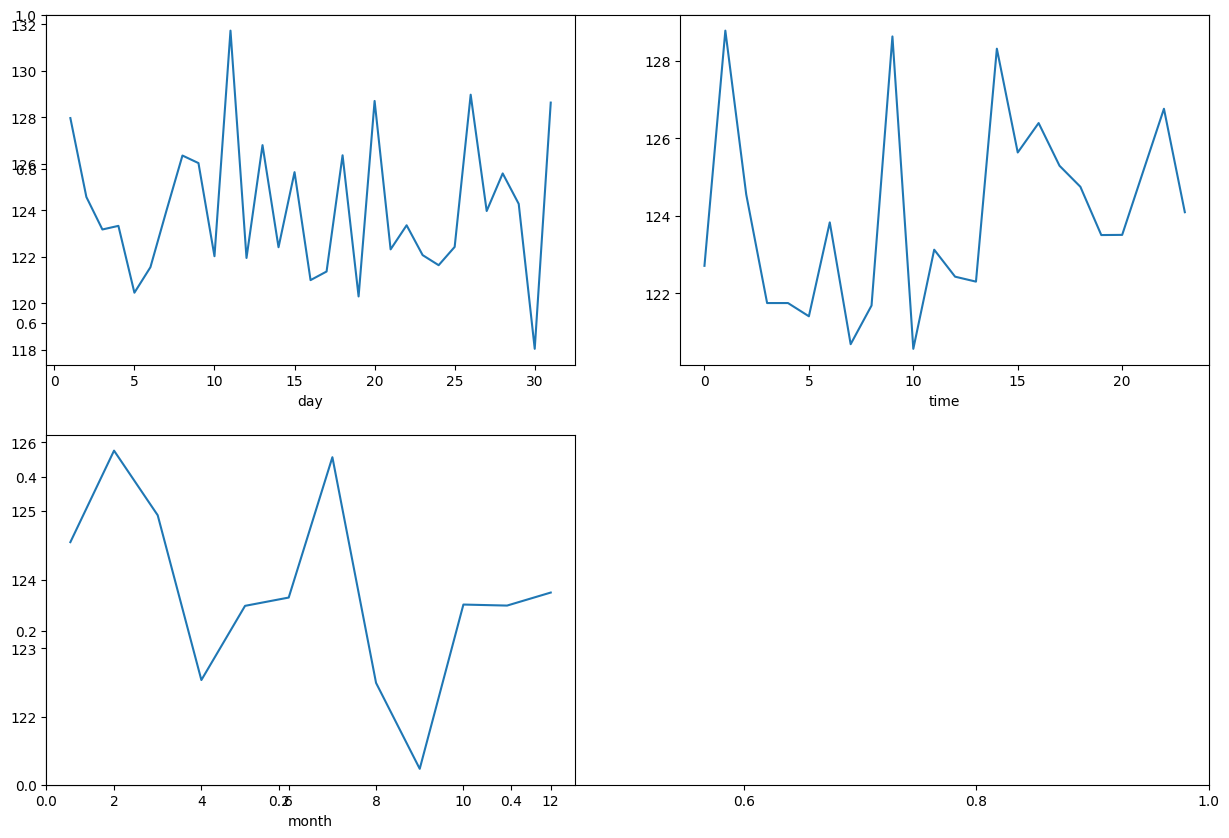

In [35]:
features = ['day', 'time', 'month']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    df.groupby(col).mean()['count'].plot()
plt.show()

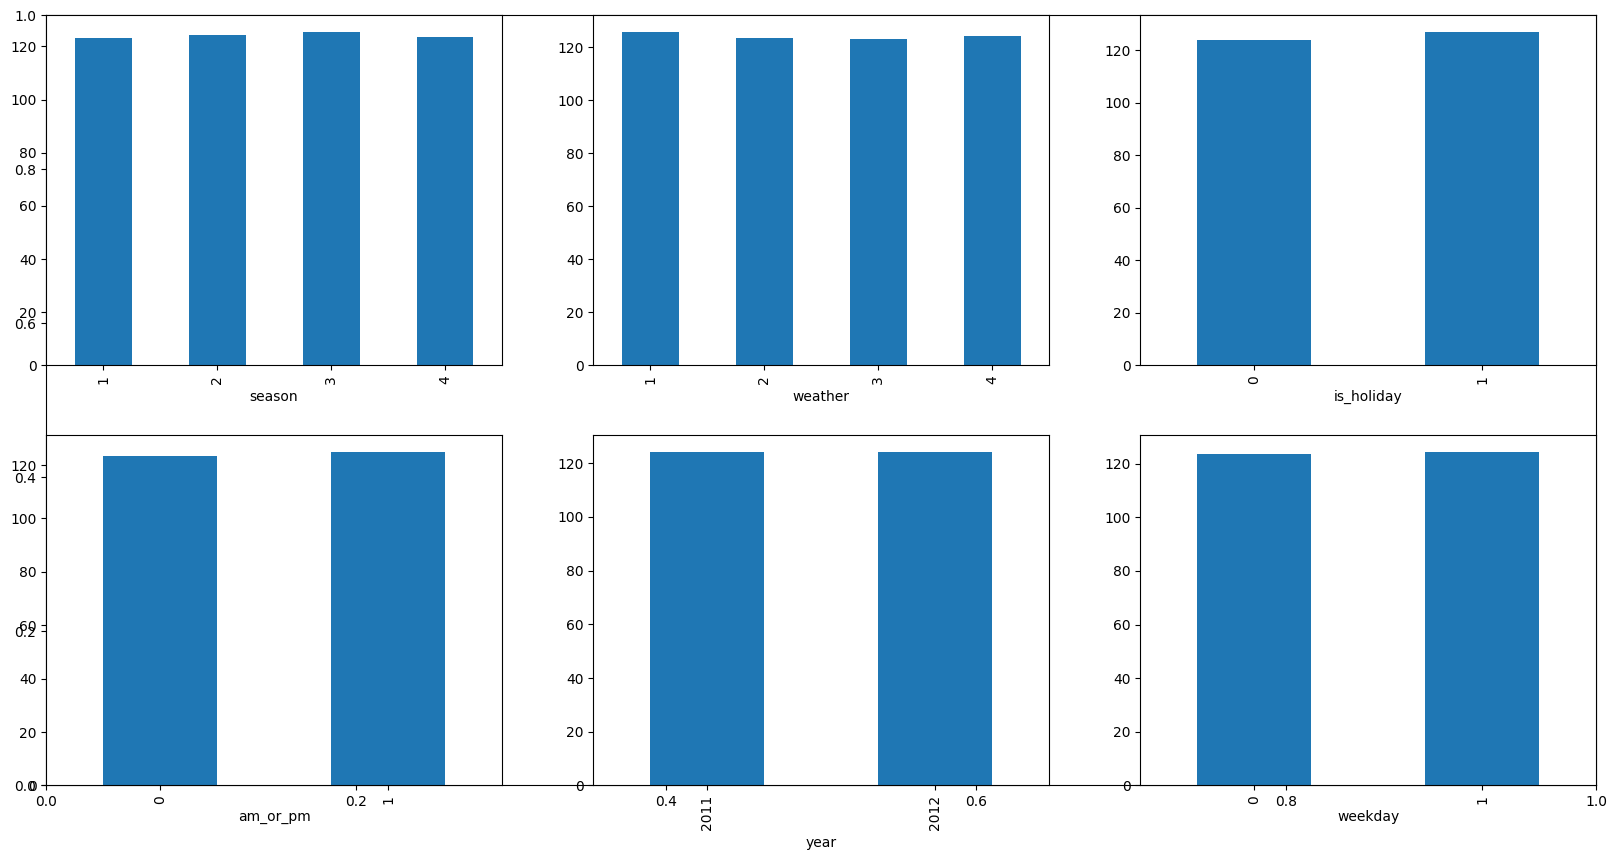

In [36]:
features = ['season', 'weather', 'is_holiday',\
            'am_or_pm', 'year', 'weekday']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 3, i + 1)
    df.groupby(col).mean()['count'].plot.bar()
plt.show()

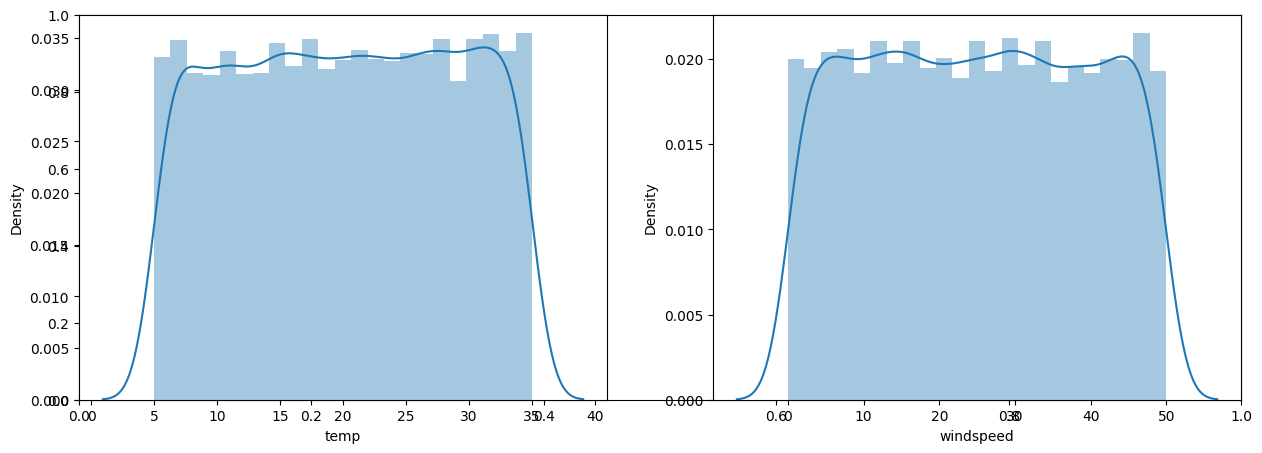

In [37]:
features = ['temp', 'windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sns.distplot(df[col])
plt.show()

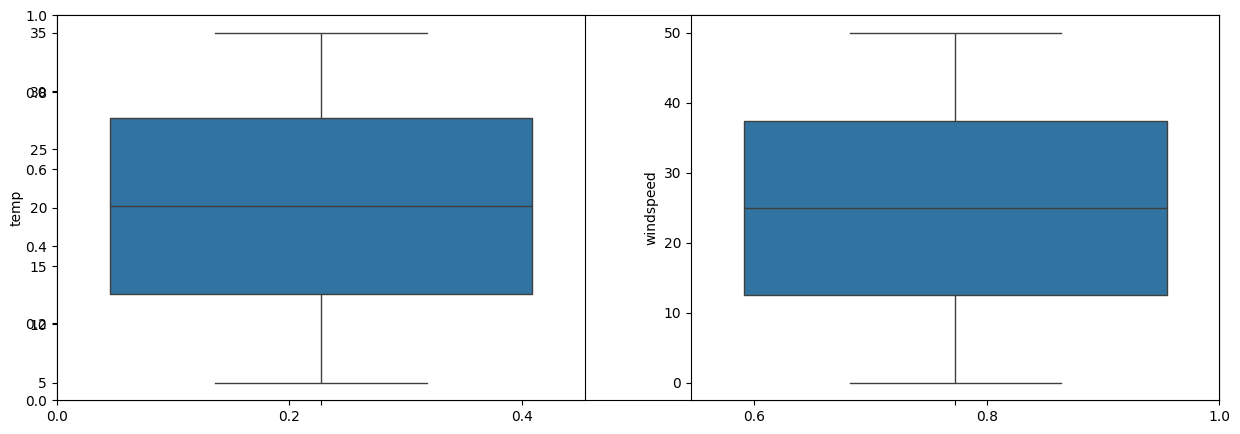

In [38]:
features = ['temp', 'windspeed']

plt.subplots(figsize=(15, 5))
for i, col in enumerate(features):
  plt.subplot(1, 2, i + 1)
  sns.boxplot(df[col])
plt.show()

In [39]:
num_rows = df.shape[0] - df[df['windspeed']<32].shape[0]
print(f'Number of rows that will be lost if we remove outliers is equal to {num_rows}.')

Number of rows that will be lost if we remove outliers is equal to 3891.


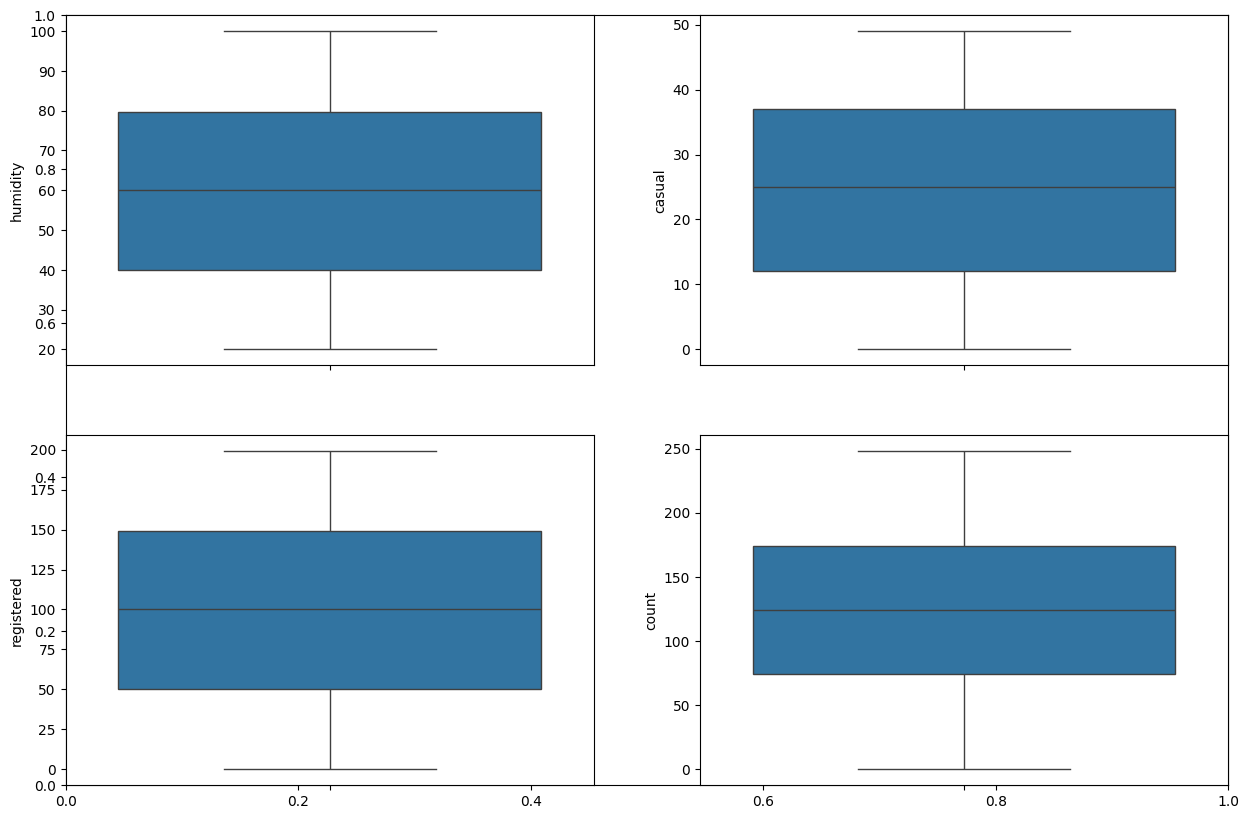

In [40]:
features = ['humidity', 'casual', 'registered', 'count']

plt.subplots(figsize=(15, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(df[col])
plt.show()

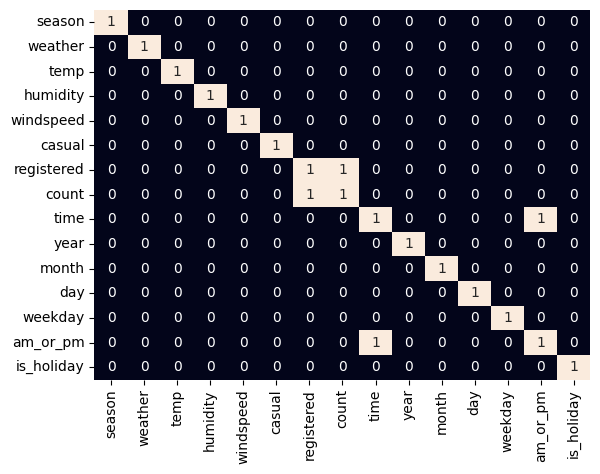

In [41]:
sns.heatmap(df.corr() > 0.8, annot=True, cbar=False)
plt.show()

In [42]:
df.drop(['registered', 'time'], axis=1, inplace=True)
df = df[(df['windspeed'] < 32) & (df['humidity'] > 0)]

In [43]:
from re import X
features = df.drop(['count'], axis = 1)
target = df['count'].values

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5596, 12), (1399, 12), (5596,), (1399,))

In [44]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
models = [LinearRegression(), Lasso(), RandomForestRegressor(), Ridge()]

for i in range(len(models)):
  models[i].fit(X_train, y_train)
  train_preds = models[i].predict(X_train)
  test_preds = models[i].predict(X_test)
  print(f'{models[i]} :')
  print('Training Error : ', mae(y_train, train_preds))
  print('Validation Error : ', mae(y_test, test_preds))
  print()

LinearRegression() :
Training Error :  3306.95911572085
Validation Error :  3327.811143644114

Lasso() :
Training Error :  3312.9814488789025
Validation Error :  3331.03563554894

RandomForestRegressor() :
Training Error :  485.40259953538236
Validation Error :  3437.9445650464613

Ridge() :
Training Error :  3306.959122856491
Validation Error :  3327.8203979695145



In [46]:
import pickle

best_model = RandomForestRegressor()
best_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [47]:
sample_input = X_test[0].reshape(1, -1)
prediction = best_model.predict(sample_input)

print(f"Test Input (Scaled): {sample_input}")
print(f"Predicted Count: {prediction[0]}")
print(f"Actual Count: {y_test[0]}")

Test Input (Scaled): [[ 1.33498814 -0.43871583  1.36715127 -1.27090978  0.67110692 -0.52534953
  -0.48622201  1.48091137  1.41583649  0.63831393 -1.01078005 -0.22646604]]
Predicted Count: 100.18
Actual Count: 21


In [48]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Best model saved as best_model.pkl")

Best model saved as best_model.pkl
